# LiDAR processing step 2: MMDetection3D, PointPillars, conversion to BEV
- NOTE: Our BEV grid will be (x= [0, 250]m; y: [-90, 90]m)
- we use resolution 0.2m along all three axes, small enough that the sparse3Dconv can make sense of pedestrians. 

--> 
- point_cloud_range = [0.0, -90.0, -3.0, 250.0, 90.0, 5.0]
- voxel_size = [0.2, 0.2, 0.2]
- grid_size = [1250, 900, 40]      # [x, y, z]
- sparse_shape = [41, 900, 1250]   # [z+1, y, x]
- out_size_factor = 8

- z∈[-5,3] meters (MMDetection3D PointPillars nuScenes config uses this range for z-axis, so good place to start: https://mmdetection3d.readthedocs.io/en/latest/advanced_guides/datasets/nuscenes.html) 
- [-5, 3] is low enough to include road dips / slopes and high enough to include pedestrians, cars, poles, and other near-road objects. We are essentially restricting the z-axis to a physically relevant region to save compute.

In [1]:
# ============================================================
# Load BEV LiDAR points saved as .bin
# ============================================================

import numpy as np
from pathlib import Path

# Path to saved file
bin_path = Path("/home/edgelab/multimodal-MoE/outputs/tmp/060350_fov_points_ego_xyzi.bin")

# ------------------------------------------------------------
# Read raw binary float32 values
# ------------------------------------------------------------

raw = np.fromfile(bin_path, dtype=np.float32)
print(f"raw.shape: {raw.shape}")

# ------------------------------------------------------------
# Reshape into (N,4) → [x,y,z,intensity]
# ------------------------------------------------------------

fov_points_ego_xyzi = raw.reshape(-1, 4)
print(f"fov_points_ego_xyzi.shape: {fov_points_ego_xyzi.shape}")

# ------------------------------------------------------------
# Diagnostics
# ------------------------------------------------------------

print("Loaded file:", bin_path)
print("Dtype:", fov_points_ego_xyzi.dtype)
print("First point:", fov_points_ego_xyzi[0] if len(fov_points_ego_xyzi) else "EMPTY")


raw.shape: (295532,)
fov_points_ego_xyzi.shape: (73883, 4)
Loaded file: /home/edgelab/multimodal-MoE/outputs/tmp/060350_fov_points_ego_xyzi.bin
Dtype: float32
First point: [47.478405 56.58517   8.407365 62.      ]


In [2]:
# Imports + coherent LiDAR spatial config for the default BEVFusion-style stack
# Pipeline:
# points -> voxelization -> HardSimpleVFE -> SparseEncoder -> SECOND -> SECONDFPN

import numpy as np
import torch
import matplotlib.pyplot as plt

from mmengine.registry import init_default_scope
from mmcv.ops import Voxelization

from mmdet3d.models.voxel_encoders import HardSimpleVFE
from mmdet3d.models.middle_encoders import SparseEncoder
from mmdet3d.models.backbones import SECOND
from mmdet3d.models.necks import SECONDFPN

init_default_scope("mmdet3d")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# ------------------------------------------------------------
# Required detection range
# point_cloud_range = [x_min, y_min, z_min, x_max, y_max, z_max]
# ------------------------------------------------------------
X_MIN, Y_MIN, Z_MIN = 0.0,  -90.0, -3.0
X_MAX, Y_MAX, Z_MAX = 250.0,  90.0,  5.0

point_cloud_range = [X_MIN, Y_MIN, Z_MIN, X_MAX, Y_MAX, Z_MAX]

# ------------------------------------------------------------
# Coherent voxel sizes
# We choose grid sizes that play nicely with the downstream
# stride pattern:
#   NX = 1248, NY = 896, NZ = 40
#
# That implies:
#   voxel_x = 250 / 1248
#   voxel_y = 180 / 896
#   voxel_z = 8 / 40 = 0.2
# ------------------------------------------------------------
NX = 1248
NY = 896
NZ = 40

VOXEL_X = (X_MAX - X_MIN) / NX
VOXEL_Y = (Y_MAX - Y_MIN) / NY
VOXEL_Z = (Z_MAX - Z_MIN) / NZ

voxel_size = [VOXEL_X, VOXEL_Y, VOXEL_Z]

# SparseEncoder expects [z, y, x] with a +1 on z
sparse_shape = [NZ + 1, NY, NX]

print("point_cloud_range:", point_cloud_range)
print("voxel_size:", voxel_size)
print("grid_size [x, y, z]:", [NX, NY, NZ])
print("sparse_shape [z+1, y, x]:", sparse_shape)


2026-03-14 08:46:45.327900159 [W:onnxruntime:Default, device_discovery.cc:164 DiscoverDevicesForPlatform] GPU device discovery failed: device_discovery.cc:89 ReadFileContents Failed to open file: "/sys/class/drm/card0/device/vendor"
/home/edgelab/miniconda3/envs/multimodal-moe/lib/python3.10/site-packages/mmengine/optim/optimizer/zero_optimizer.py:11: DeprecationWarning: `TorchScript` support for functional optimizers is deprecated and will be removed in a future PyTorch release. Consider using the `torch.compile` optimizer instead.
  from torch.distributed.optim import \


device: cuda
point_cloud_range: [0.0, -90.0, -3.0, 250.0, 90.0, 5.0]
voxel_size: [0.20032051282051283, 0.20089285714285715, 0.2]
grid_size [x, y, z]: [1248, 896, 40]
sparse_shape [z+1, y, x]: [41, 896, 1248]


In [3]:
# Load ego-frame XYZI points and filter to the voxelization region

pts_xyzi = fov_points_ego_xyzi.astype(np.float32)
print("Raw fov_points_ego_xyzi shape:", pts_xyzi.shape)

mask = (
    (pts_xyzi[:, 0] >= X_MIN) & (pts_xyzi[:, 0] < X_MAX) &
    (pts_xyzi[:, 1] >= Y_MIN) & (pts_xyzi[:, 1] < Y_MAX) &
    (pts_xyzi[:, 2] >= Z_MIN) & (pts_xyzi[:, 2] < Z_MAX)
)

pts_xyzi = pts_xyzi[mask]
print("Points after filtering:", pts_xyzi.shape)

# HardSimpleVFE expects 5 input features.
# Current tensor is [x, y, z, intensity], so append one dummy feature.
dummy_feat = np.zeros((pts_xyzi.shape[0], 1), dtype=np.float32)
pts_xyzif = np.concatenate([pts_xyzi, dummy_feat], axis=1)

points_tensor = torch.from_numpy(pts_xyzif).to(device)
print("Points passed to VFE:", tuple(points_tensor.shape))


Raw fov_points_ego_xyzi shape: (73883, 4)
Points after filtering: (59063, 4)
Points passed to VFE: (59063, 5)


In [4]:
# LiDAR front-end:
# points -> voxels -> HardSimpleVFE -> SparseEncoder -> dense BEV feature map

voxel_layer = Voxelization(
    voxel_size=voxel_size,
    point_cloud_range=point_cloud_range,
    max_num_points=10,
    max_voxels=120000,
)

voxel_encoder = HardSimpleVFE(
    num_features=5
).to(device).eval()

middle_encoder = SparseEncoder(
    in_channels=5,
    sparse_shape=sparse_shape,
    order=("conv", "norm", "act"),
    norm_cfg=dict(type="BN1d", eps=1e-3, momentum=0.01),
    base_channels=16,
    output_channels=256,
    encoder_channels=((16,), (32, 32, 32), (64, 64, 64), (64, 64, 64)),
    encoder_paddings=((1,), (1, 1, 1), (1, 1, 1), ((0, 1, 1), 1, 1)),
    block_type="conv_module",
).to(device).eval()

with torch.no_grad():
    # Hard voxelization
    voxels, coors, num_points = voxel_layer(points_tensor)

    print("voxels shape:", tuple(voxels.shape))
    print("coors shape:", tuple(coors.shape))
    print("num_points shape:", tuple(num_points.shape))

    # Add batch index because this notebook uses one frame only
    batch_idx = torch.zeros((coors.shape[0], 1), dtype=coors.dtype, device=coors.device)
    coors_batch = torch.cat([batch_idx, coors], dim=1)

    # Per-voxel feature encoding
    voxel_features = voxel_encoder(voxels, num_points, coors_batch)

    # Sparse 3D conv encoder -> dense BEV feature map
    bev_feature_map = middle_encoder(
        voxel_features,
        coors_batch,
        batch_size=1
    )

    print("coors_batch shape:", tuple(coors_batch.shape))
    print("voxel_features shape:", tuple(voxel_features.shape))
    print("bev_feature_map shape:", tuple(bev_feature_map.shape))
    print("BEV mean activation:", bev_feature_map.mean().item())
    print("BEV std activation:", bev_feature_map.std().item())


voxels shape: (30566, 10, 5)
coors shape: (30566, 3)
num_points shape: (30566,)
coors_batch shape: (30566, 4)
voxel_features shape: (30566, 5)
bev_feature_map shape: (1, 512, 112, 156)
BEV mean activation: 1.294243812328174e-14
BEV std activation: 1.0843416279899404e-13


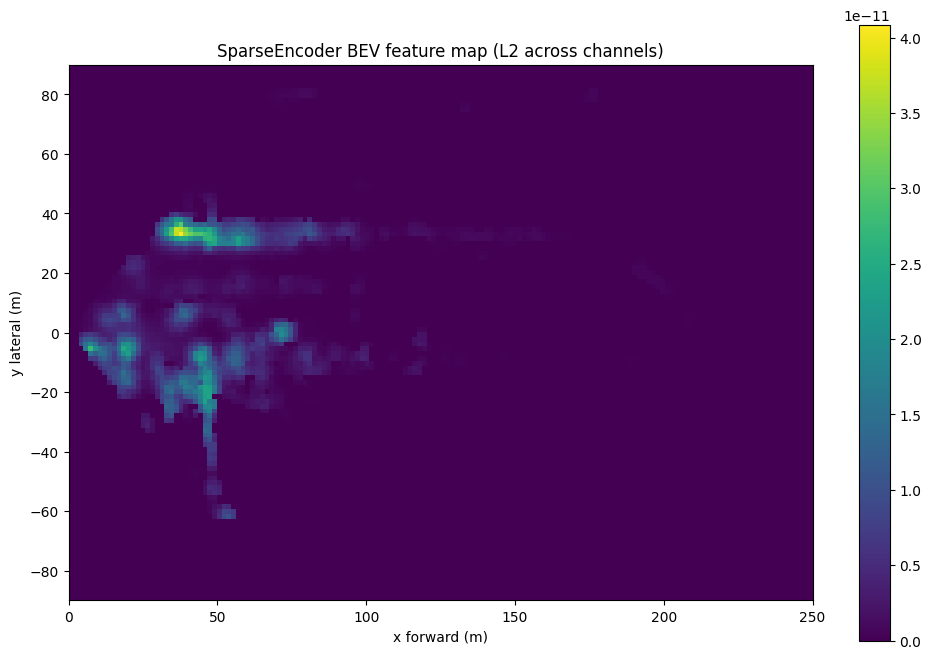

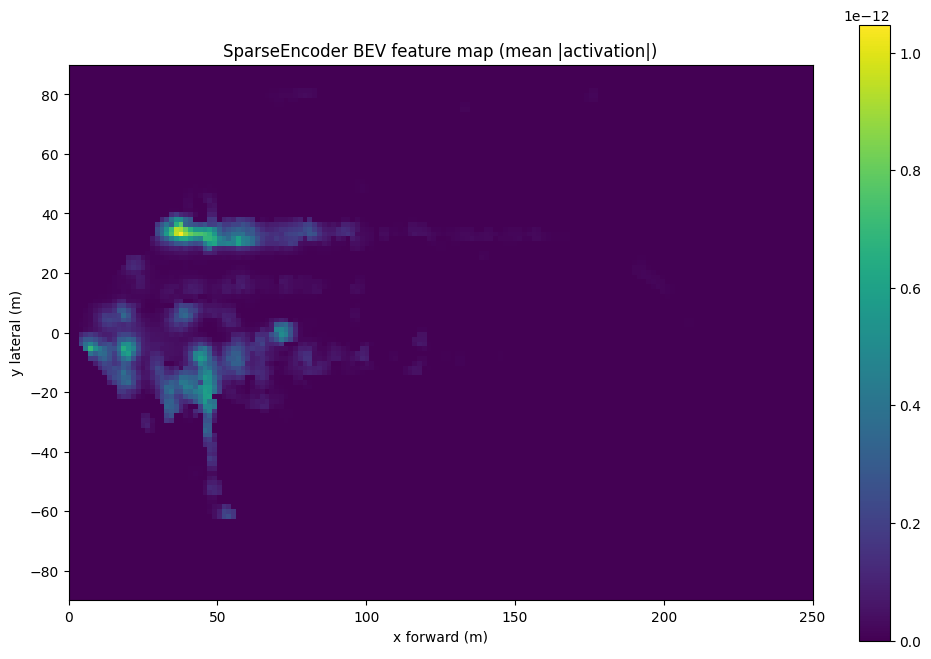

In [5]:
# Visualize the dense BEV feature map from SparseEncoder

bev = bev_feature_map.detach().cpu()[0]   # [C, H, W]

bev_l2 = torch.norm(bev, dim=0).numpy()
bev_mean = bev.abs().mean(dim=0).numpy()

extent = [X_MIN, X_MAX, Y_MIN, Y_MAX]

plt.figure(figsize=(12, 8))
plt.imshow(bev_l2, origin="lower", extent=extent, aspect="equal")
plt.title("SparseEncoder BEV feature map (L2 across channels)")
plt.xlabel("x forward (m)")
plt.ylabel("y lateral (m)")
plt.colorbar()
plt.show()

plt.figure(figsize=(12, 8))
plt.imshow(bev_mean, origin="lower", extent=extent, aspect="equal")
plt.title("SparseEncoder BEV feature map (mean |activation|)")
plt.xlabel("x forward (m)")
plt.ylabel("y lateral (m)")
plt.colorbar()
plt.show()


In [6]:
print(bev_feature_map.shape)


torch.Size([1, 512, 112, 156])


In [8]:
# Run SECOND + SECONDFPN on the BEV feature map

from mmdet3d.models.backbones import SECOND
from mmdet3d.models.necks import SECONDFPN

# Match SECOND input channels to the actual SparseEncoder output
bev_in_channels = bev_feature_map.shape[1]
print("bev_feature_map shape:", tuple(bev_feature_map.shape))
print("Using SECOND in_channels =", bev_in_channels)

bev_backbone = SECOND(
    in_channels=bev_in_channels,   # <-- important fix
    out_channels=[128, 256],
    layer_nums=[5, 5],
    layer_strides=[1, 2],
    norm_cfg=dict(type="BN", eps=1e-3, momentum=0.01),
    conv_cfg=dict(type="Conv2d", bias=False),
).to(device).eval()

bev_neck = SECONDFPN(
    in_channels=[128, 256],
    out_channels=[256, 256],
    upsample_strides=[1, 2],
    norm_cfg=dict(type="BN", eps=1e-3, momentum=0.01),
    upsample_cfg=dict(type="deconv", bias=False),
    use_conv_for_no_stride=True,
).to(device).eval()

with torch.no_grad():
    backbone_feats = bev_backbone(bev_feature_map)
    neck_feats = bev_neck(backbone_feats)

    print("Number of backbone feature maps:", len(backbone_feats))
    for i, feat in enumerate(backbone_feats):
        print(f"backbone_feats[{i}] shape:", tuple(feat.shape))

    print("Number of neck feature maps:", len(neck_feats))
    for i, feat in enumerate(neck_feats):
        print(f"neck_feats[{i}] shape:", tuple(feat.shape))


bev_feature_map shape: (1, 512, 112, 156)
Using SECOND in_channels = 512
Number of backbone feature maps: 2
backbone_feats[0] shape: (1, 128, 112, 156)
backbone_feats[1] shape: (1, 256, 56, 78)
Number of neck feature maps: 1
neck_feats[0] shape: (1, 512, 112, 156)


backbone_feats[0] shape: (1, 128, 112, 156)
effective BEV resolution: dx=1.603 m, dy=1.607 m


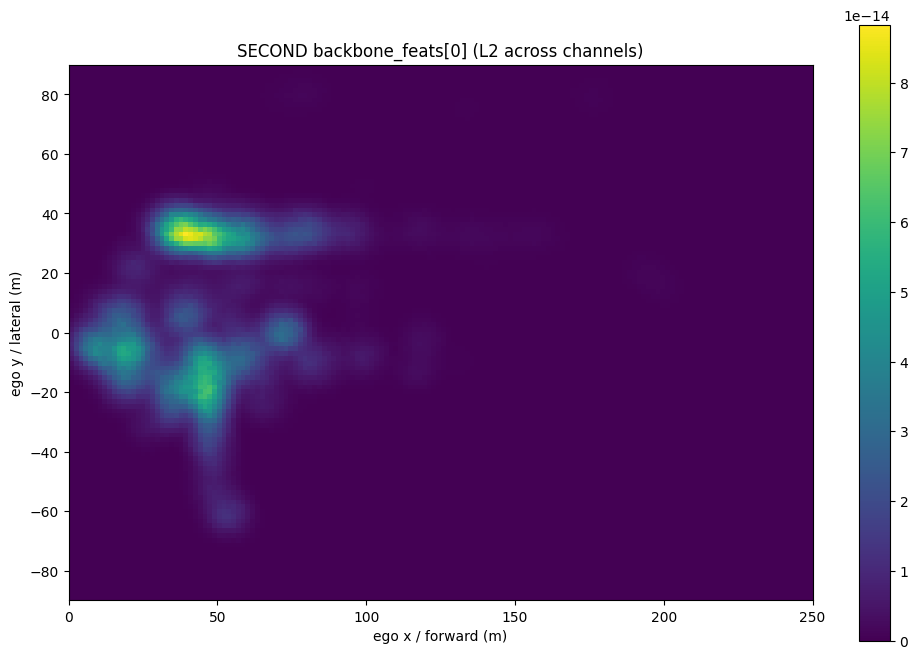

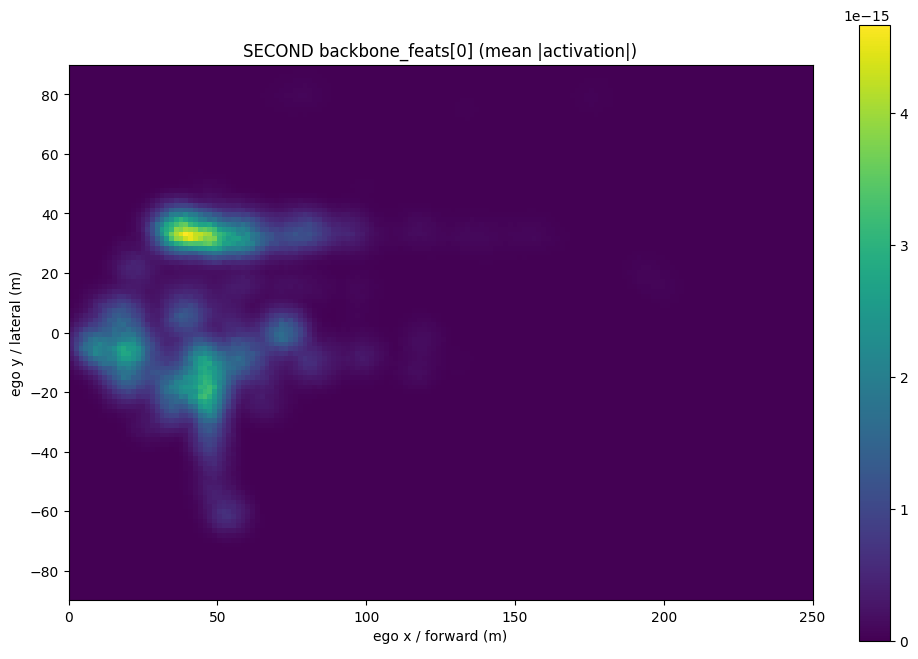

backbone_feats[1] shape: (1, 256, 56, 78)
effective BEV resolution: dx=3.205 m, dy=3.214 m


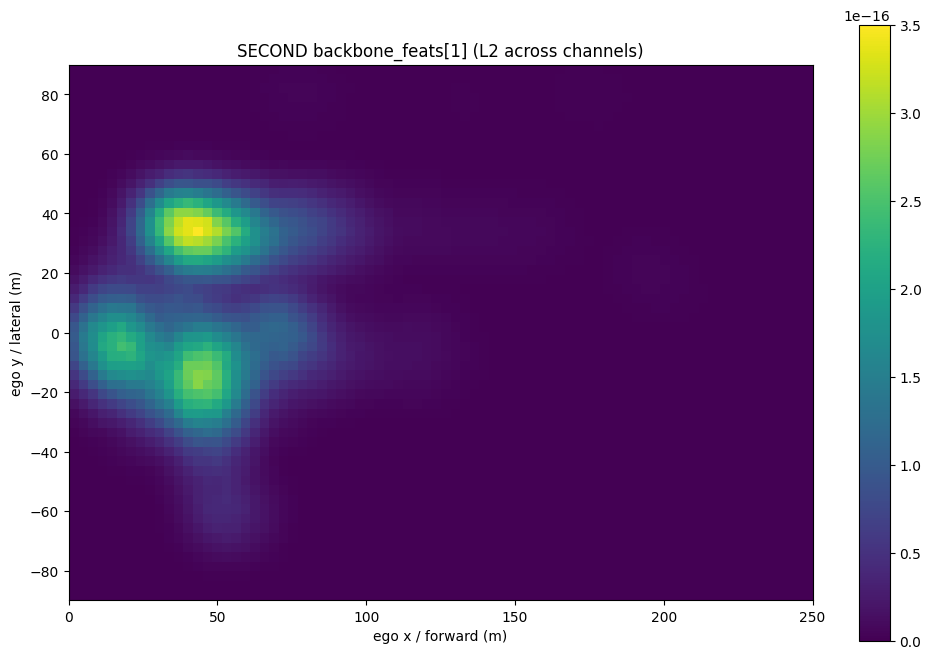

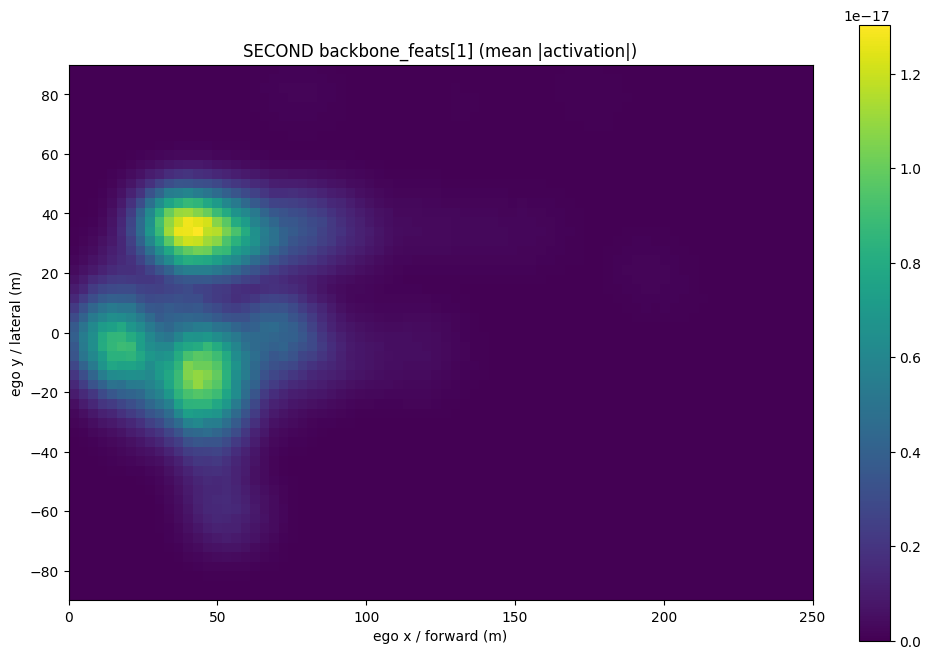

neck_feats[0] shape: (1, 512, 112, 156)
effective BEV resolution: dx=1.603 m, dy=1.607 m


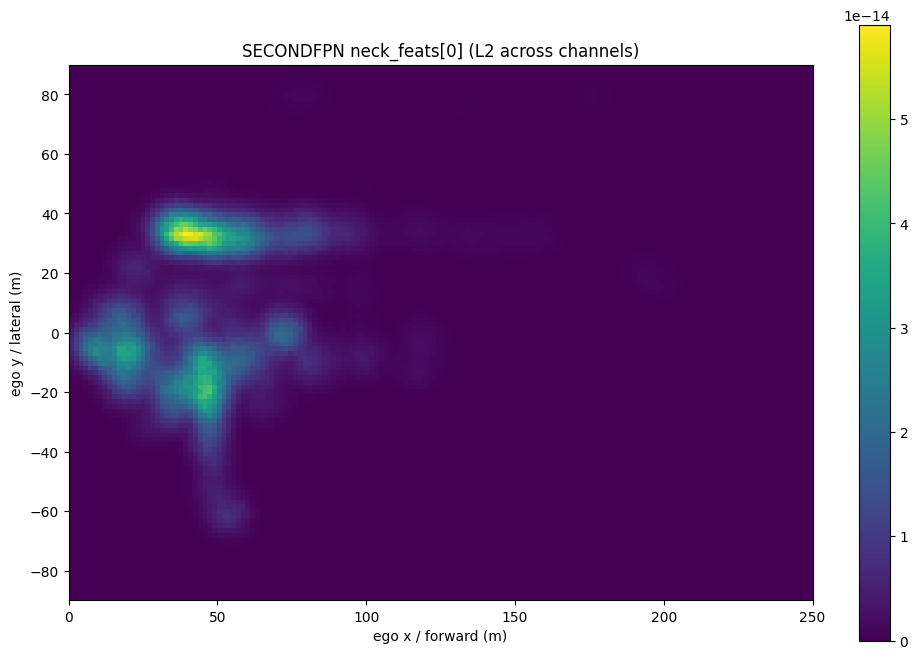

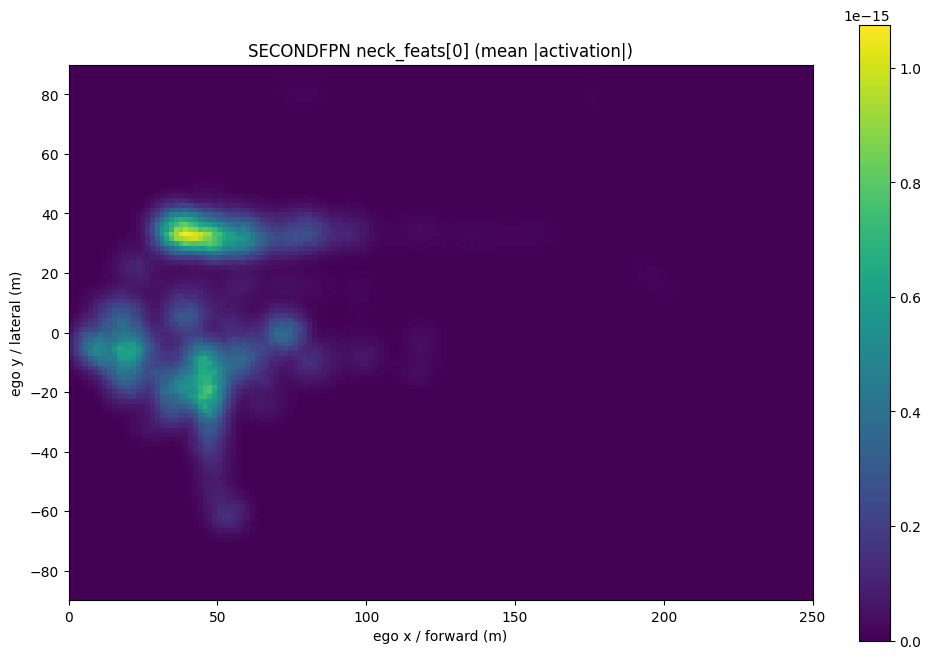

neck_feats[0] full fused shape: (1, 512, 112, 156)
SECONDFPN fused contribution 0 shape: (1, 256, 112, 156)
effective BEV resolution: dx=1.603 m, dy=1.607 m


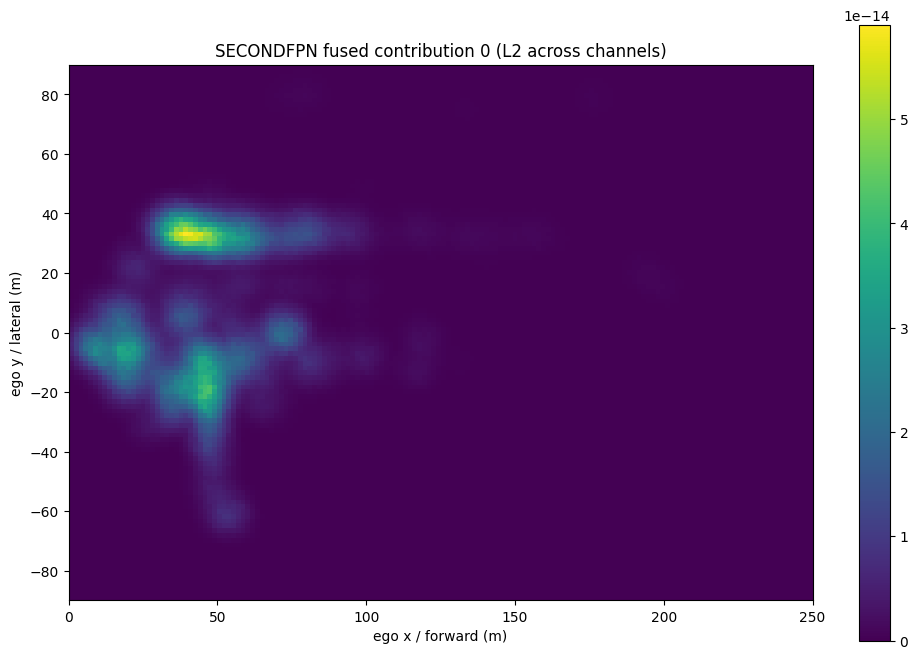

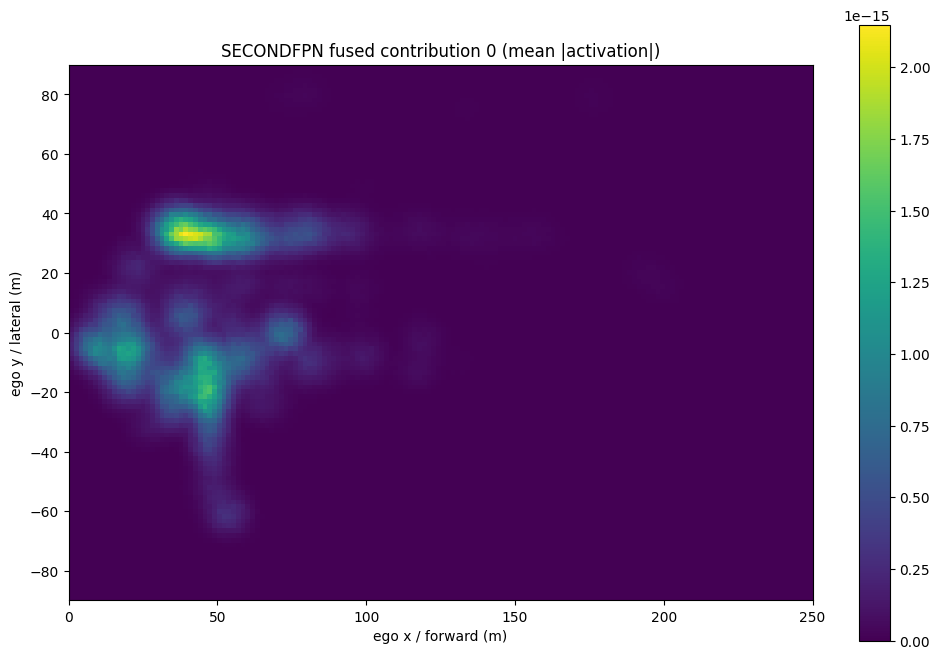

SECONDFPN fused contribution 1 shape: (1, 256, 112, 156)
effective BEV resolution: dx=1.603 m, dy=1.607 m


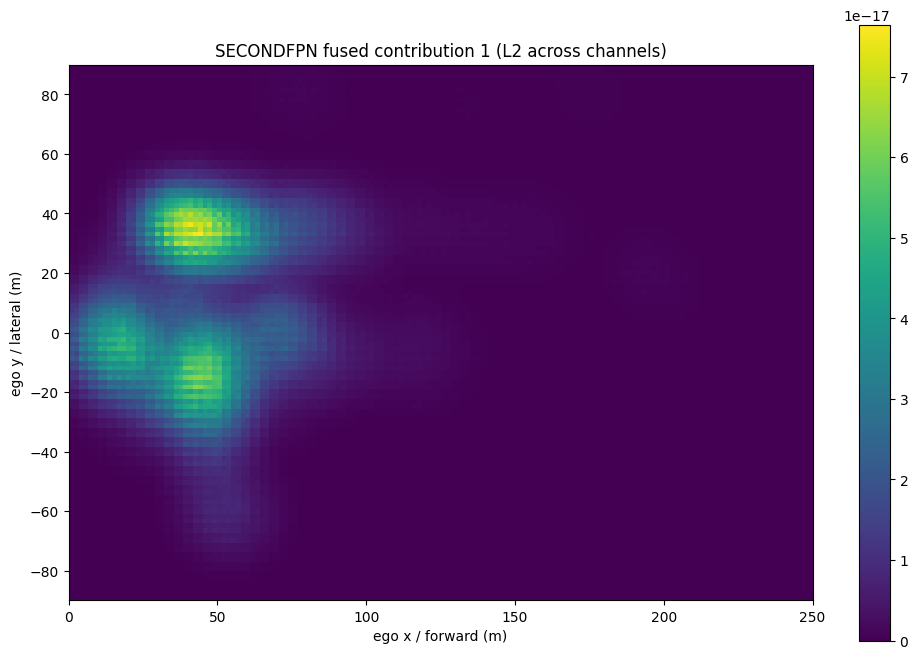

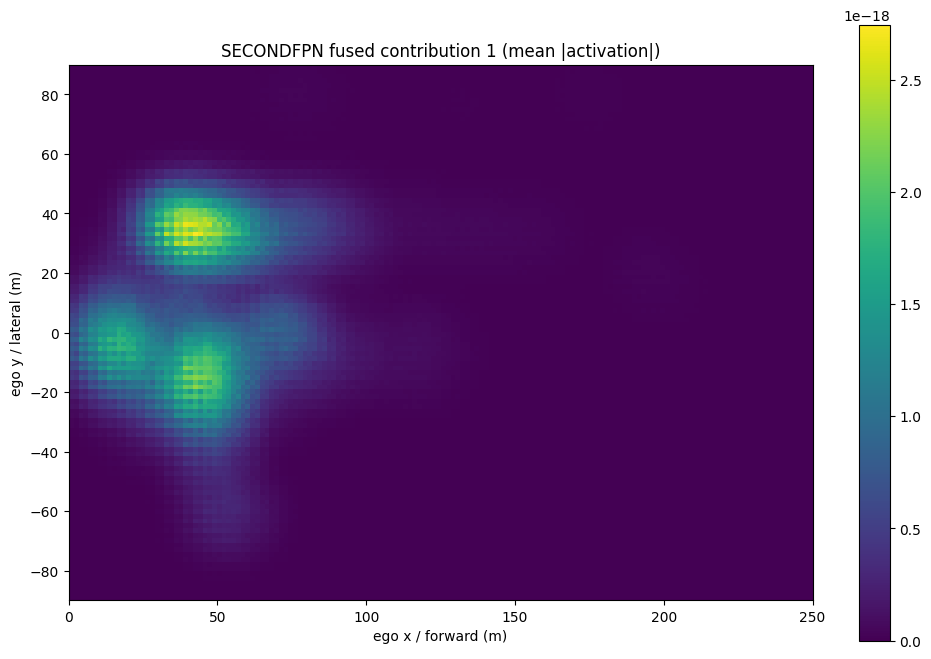

In [11]:
# Visualize backbone and neck feature maps in ego-frame coordinates
# Also visualize how the fused neck feature map splits into contributions
# from the different backbone resolutions.

def summarize_bev_feature(x):
    # x: [1, C, H, W] -> summaries [H, W]
    x = x.detach().cpu()[0]
    x_l2 = torch.norm(x, dim=0).numpy()
    x_mean = x.abs().mean(dim=0).numpy()
    return x_l2, x_mean

def bev_extent_from_tensor(feat, x_min, x_max, y_min, y_max):
    # Returns plotting extent and spatial size
    _, _, H, W = feat.shape
    extent = [x_min, x_max, y_min, y_max]
    return extent, H, W

# ------------------------------------------------------------
# 1) Backbone feature maps
# ------------------------------------------------------------
for i, feat in enumerate(backbone_feats):
    extent, H, W = bev_extent_from_tensor(feat, X_MIN, X_MAX, Y_MIN, Y_MAX)
    feat_l2, feat_mean = summarize_bev_feature(feat)

    dx = (X_MAX - X_MIN) / W
    dy = (Y_MAX - Y_MIN) / H

    print(f"backbone_feats[{i}] shape: {tuple(feat.shape)}")
    print(f"effective BEV resolution: dx={dx:.3f} m, dy={dy:.3f} m")

    plt.figure(figsize=(12, 8))
    plt.imshow(feat_l2, origin="lower", extent=extent, aspect="equal")
    plt.title(f"SECOND backbone_feats[{i}] (L2 across channels)")
    plt.xlabel("ego x / forward (m)")
    plt.ylabel("ego y / lateral (m)")
    plt.colorbar()
    plt.show()

    plt.figure(figsize=(12, 8))
    plt.imshow(feat_mean, origin="lower", extent=extent, aspect="equal")
    plt.title(f"SECOND backbone_feats[{i}] (mean |activation|)")
    plt.xlabel("ego x / forward (m)")
    plt.ylabel("ego y / lateral (m)")
    plt.colorbar()
    plt.show()

# ------------------------------------------------------------
# 2) Neck feature maps
# ------------------------------------------------------------
for i, feat in enumerate(neck_feats):
    extent, H, W = bev_extent_from_tensor(feat, X_MIN, X_MAX, Y_MIN, Y_MAX)
    feat_l2, feat_mean = summarize_bev_feature(feat)

    dx = (X_MAX - X_MIN) / W
    dy = (Y_MAX - Y_MIN) / H

    print(f"neck_feats[{i}] shape: {tuple(feat.shape)}")
    print(f"effective BEV resolution: dx={dx:.3f} m, dy={dy:.3f} m")

    plt.figure(figsize=(12, 8))
    plt.imshow(feat_l2, origin="lower", extent=extent, aspect="equal")
    plt.title(f"SECONDFPN neck_feats[{i}] (L2 across channels)")
    plt.xlabel("ego x / forward (m)")
    plt.ylabel("ego y / lateral (m)")
    plt.colorbar()
    plt.show()

    plt.figure(figsize=(12, 8))
    plt.imshow(feat_mean, origin="lower", extent=extent, aspect="equal")
    plt.title(f"SECONDFPN neck_feats[{i}] (mean |activation|)")
    plt.xlabel("ego x / forward (m)")
    plt.ylabel("ego y / lateral (m)")
    plt.colorbar()
    plt.show()

# ------------------------------------------------------------
# 3) Split the fused neck feature map into per-scale channel groups
#    This helps visualize how different backbone resolutions
#    contribute to the fused neck output.
# ------------------------------------------------------------
# Here SECONDFPN concatenates two 256-channel branches:
# first 256 channels  = contribution from one scale
# second 256 channels = contribution from the other scale

neck0 = neck_feats[0]
print("neck_feats[0] full fused shape:", tuple(neck0.shape))

neck_part_0 = neck0[:, :256, :, :]
neck_part_1 = neck0[:, 256:, :, :]

parts = [
    ("SECONDFPN fused contribution 0", neck_part_0),
    ("SECONDFPN fused contribution 1", neck_part_1),
]

for name, feat in parts:
    extent, H, W = bev_extent_from_tensor(feat, X_MIN, X_MAX, Y_MIN, Y_MAX)
    feat_l2, feat_mean = summarize_bev_feature(feat)

    dx = (X_MAX - X_MIN) / W
    dy = (Y_MAX - Y_MIN) / H

    print(f"{name} shape: {tuple(feat.shape)}")
    print(f"effective BEV resolution: dx={dx:.3f} m, dy={dy:.3f} m")

    plt.figure(figsize=(12, 8))
    plt.imshow(feat_l2, origin="lower", extent=extent, aspect="equal")
    plt.title(f"{name} (L2 across channels)")
    plt.xlabel("ego x / forward (m)")
    plt.ylabel("ego y / lateral (m)")
    plt.colorbar()
    plt.show()

    plt.figure(figsize=(12, 8))
    plt.imshow(feat_mean, origin="lower", extent=extent, aspect="equal")
    plt.title(f"{name} (mean |activation|)")
    plt.xlabel("ego x / forward (m)")
    plt.ylabel("ego y / lateral (m)")
    plt.colorbar()
    plt.show()